# TRABAJO FINAL MODULO 5 - MACHINE LEARNING
# ALUMNO : CÉSAR MAYTA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_df = pd.read_csv('/content/telco_data_transformed.csv')
data_df

,gender,partner,dependents,phone_service,paperless_billing,churn,movies_no,movies_none,movies_yes,contract_month_to_month,...,tech_support_no,tech_support_none,tech_support_yes,device_protection_no,device_protection_none,device_protection_yes,senior_citizen,tenure,monthly_charges,total_charges
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,29.85,29.85
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0,56.95,1889.50
2,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,53.85,108.15
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,45.0,42.30,1840.75
4,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,24.0,84.80,1990.50
7039,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,72.0,103.20,7362.90
7040,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,11.0,29.60,346.45
7041,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,4.0,74.40,306.60


In [ ]:
data_df.dtypes.value_counts()

,count
float64,41


In [ ]:
data_df.isnull().sum().sum()

np.int64(11)

In [ ]:
data_df.dropna(inplace=True)

In [ ]:
data_df.isnull().sum().sum()

np.int64(0)

# CORRELACIONES

In [ ]:
corr_matrix = data_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

,churn
churn,1.000000
contract_month_to_month,0.404565
security_no,0.342235
tech_support_no,0.336877
internet_fiber_optic,0.307463
payment_electronic_check,0.301455
backup_no,0.267595
device_protection_no,0.252056
monthly_charges,0.192858
paperless_billing,0.191454


## MAPA DE CALOR DE CORRELACIONES

<Axes: >

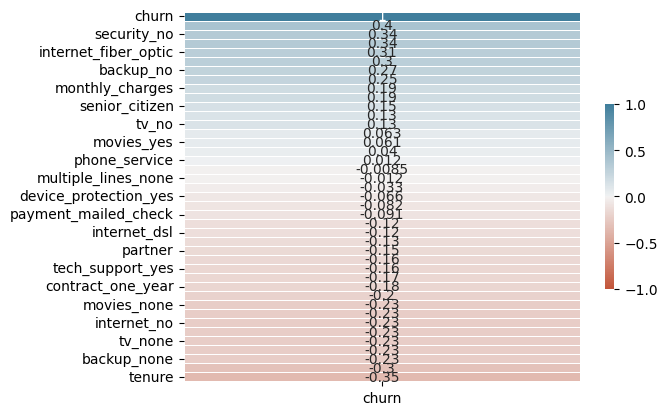

In [ ]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## FILTRAMOS POR VARIABLES QUE TENGAN UN CORRELACIÓN MAYOR A 0 Y MENOR A 1 CON CHURN

In [ ]:
corr_filtered = corr_churn[(corr_churn >= 0) & (corr_churn < 1)]
corr_filtered
cols = corr_filtered.index.tolist()
cols

['phone_service',
 'paperless_billing',
 'movies_no',
 'movies_yes',
 'contract_month_to_month',
 'security_no',
 'payment_electronic_check',
 'multiple_lines_yes',
 'internet_fiber_optic',
 'tv_no',
 'tv_yes',
 'backup_no',
 'tech_support_no',
 'device_protection_no',
 'senior_citizen',
 'monthly_charges']

## GRAFICAMOS LAS VARIABLES MAS RELEVANTES

/tmp/ipython-input-10-1571313160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_sorted.values, y=corr_sorted.index, palette="viridis")


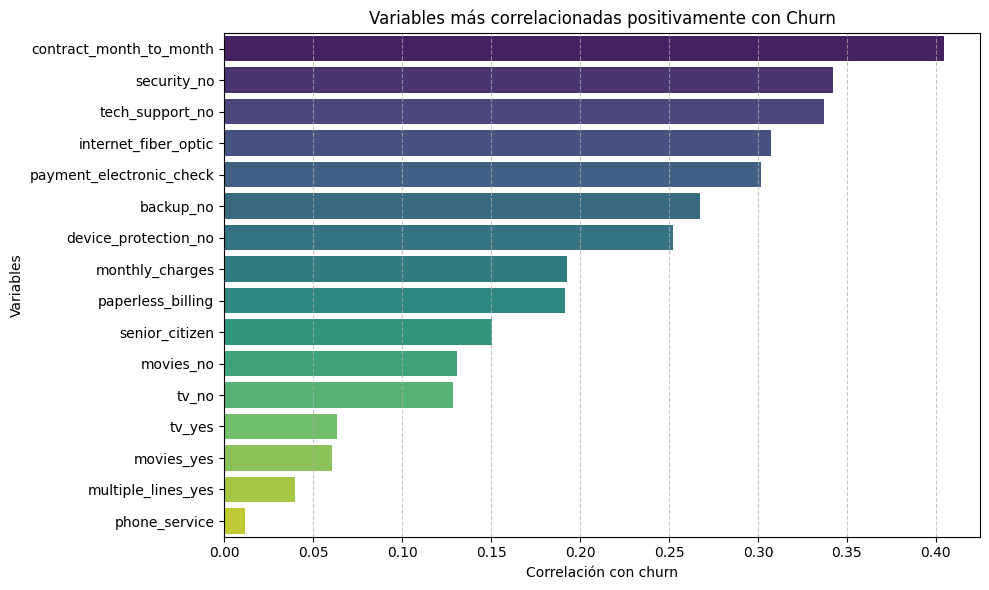

In [ ]:
corr_sorted = corr_filtered.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_sorted.values, y=corr_sorted.index, palette="viridis")
plt.title('Variables más correlacionadas positivamente con Churn')
plt.xlabel('Correlación con churn')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## CREACIÓN DE MODELOS DE MACHINE LEARNING

# DEFINIMOS VARIABLES X Y Y

In [ ]:
X = data_df[cols].values
y = data_df['churn'].values

# ENTRENAMIENTO DE MODELO

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## REGRESIÓN LOGISTICA

# DIVIDIMOS DATASET EN TRAIN TEST

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# CREACION DE MODELO CON PARAMETROS Y MOSTRAR ACCURACY

In [ ]:
model = LogisticRegression()# COLOCAR LOS PARAMETROS QUE CREAN CONVENIENTES
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.76


# MOSTRAR MATRIZ DE CONFUSIÓN

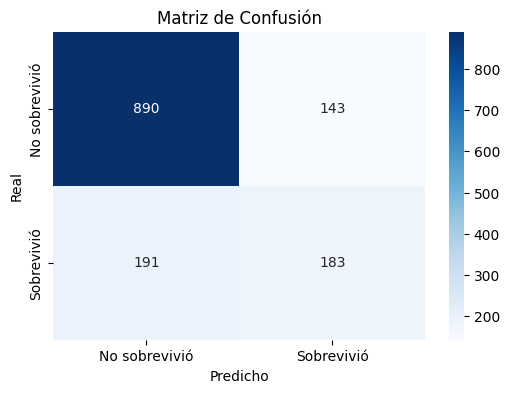

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [22]:
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
configs = [
    ('liblinear', 'l1', None),
    ('liblinear', 'l2', None),
    ('saga', 'l1', None),
    ('saga', 'l2', None),
    ('saga', 'elasticnet', 0.5),
    ('lbfgs', 'l2', None),
    ('saga', 'l1', 'balanced'),
    ('saga', 'l2', 'balanced'),
]
results = {}

for solver, penalty, class_weight in configs:
    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        continue  # Algunos solvers no admiten L1
    if penalty == 'elasticnet' and solver != 'saga':
        continue  # Solo 'saga' soporta elasticnet

    model = LogisticRegression(solver=solver, penalty=penalty, l1_ratio=0.5 if penalty == 'elasticnet' else None, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[f'{solver} - {penalty} - {class_weight}'] = report

# Imprimir reportes de clasificación
for config, report in results.items():
    print(f'Configuración: {config}')
    print(classification_report(y_test, model.predict(X_test)))
    print('-' * 80)

Configuración: liblinear - l1 - None
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84      1033
         1.0       0.57      0.49      0.53       374

    accuracy                           0.76      1407
   macro avg       0.70      0.68      0.68      1407
weighted avg       0.76      0.76      0.76      1407

--------------------------------------------------------------------------------
Configuración: liblinear - l2 - None
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84      1033
         1.0       0.57      0.49      0.53       374

    accuracy                           0.76      1407
   macro avg       0.70      0.68      0.68      1407
weighted avg       0.76      0.76      0.76      1407

--------------------------------------------------------------------------------
Configuración: saga - l1 - None
              precision    recall  f1-score   support

         0.0       0.82

## ARBOLES DE DECISIÓN

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# definirmos varios parametros
param_grid = {
    'max_depth': [3,4,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini','entropy']
}
clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(clf,param_grid,cv=5,scoring='accuracy',n_jobs=1)
grid_search.fit(X_train,y_train)

print(f"Mejores parametros: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy best model : {accuracy}')

Mejores parametros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy best model : 0.7526652452025586


/tmp/ipython-input-20-4107830542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columns, y=importances, palette='bright', saturation=2.0,


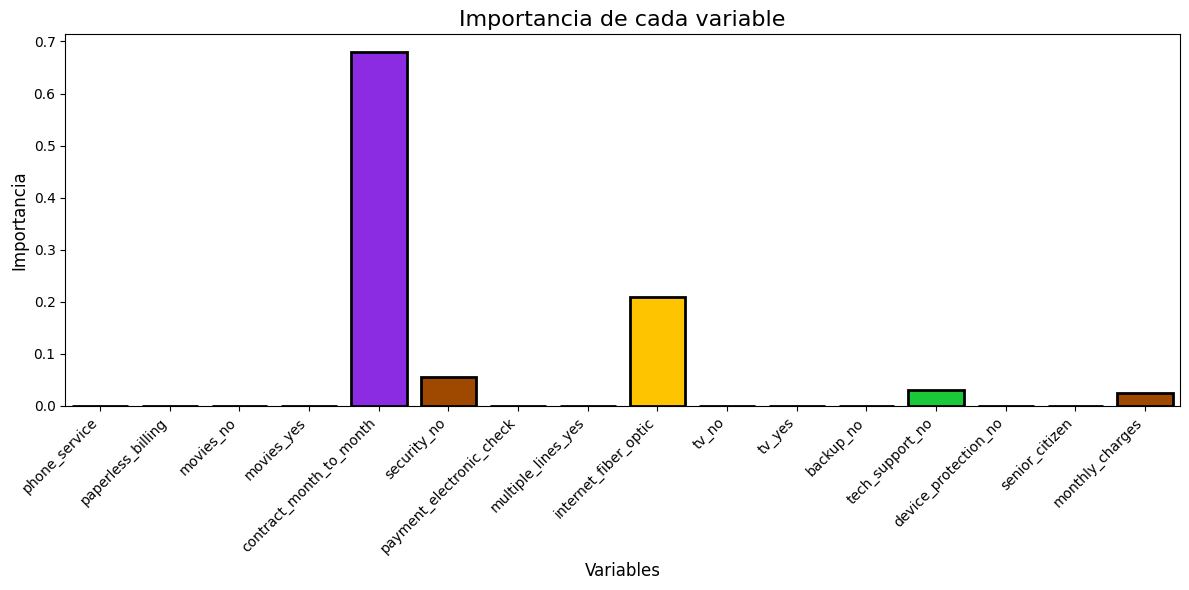

In [ ]:
importances = best_model.feature_importances_
importances
columns = cols
columns
# Asumiendo que ya tienes 'importances' y 'columns'
plt.figure(figsize=(12, 6))  # Aumenta el tamaño de la figura

sns.barplot(x=columns, y=importances, palette='bright', saturation=2.0,
            edgecolor='black', linewidth=2)

plt.title('Importancia de cada variable', fontsize=16)
plt.xticks(rotation=45, ha='right')  # Rota etiquetas del eje X
plt.ylabel('Importancia', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.tight_layout()  # Ajusta para que no se corten etiquetas
plt.show()

## RANDOM FOREST

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': np.arange(2, 20, 2),
    'min_samples_leaf': np.arange(1, 10, 2),
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

grid_search = RandomizedSearchCV(estimator=rf,param_distributions=param_dist,
                                 n_iter=20,cv=5,scoring='accuracy',
                                 n_jobs=-1,verbose=2)

grid_search.fit(X_train,y_train)

print('mejores parametros : ',grid_search.best_params_)
print('mejor puntuación : ',grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
mejores parametros :  {'n_estimators': np.int64(100), 'min_samples_split': np.int64(16), 'min_samples_leaf': np.int64(3), 'max_features': 'log2', 'max_depth': 10}
mejor puntuación :  0.7866666666666666
